## Name: Siddhi Deshpande
## Section: B-B1-11
## Branch: CSE AIML

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [2]:
df=pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.duplicated().sum()

240

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [8]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

## 1 Univariate analysis

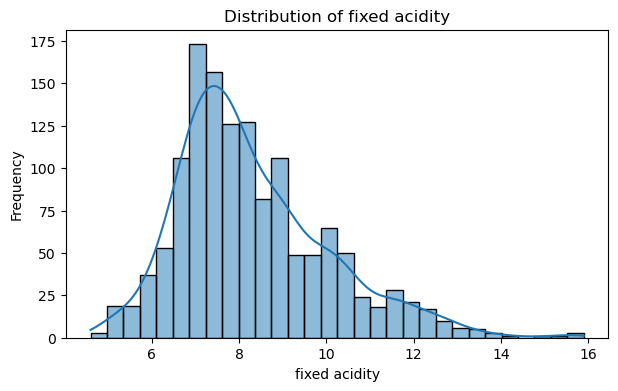

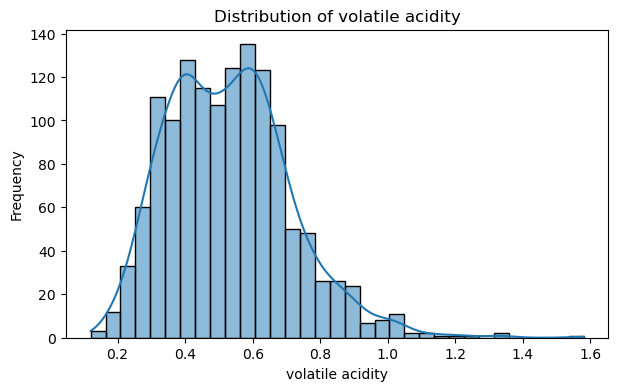

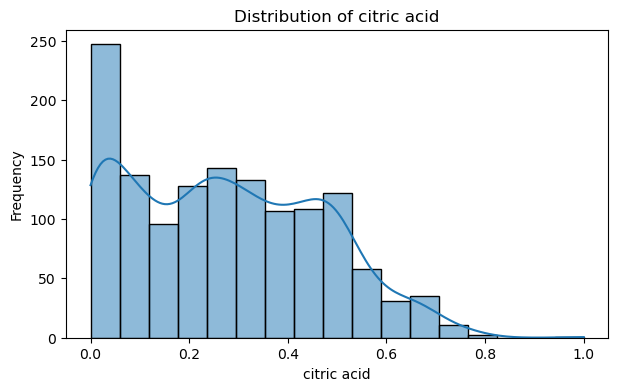

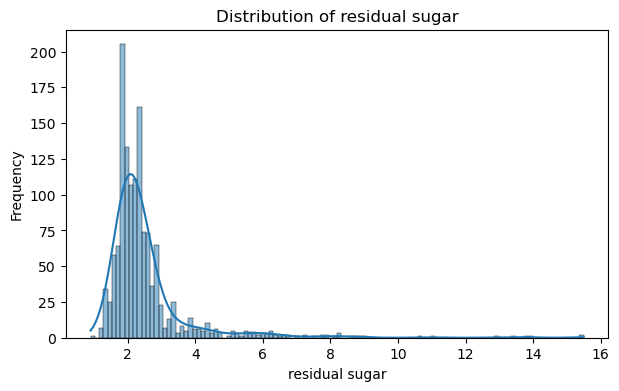

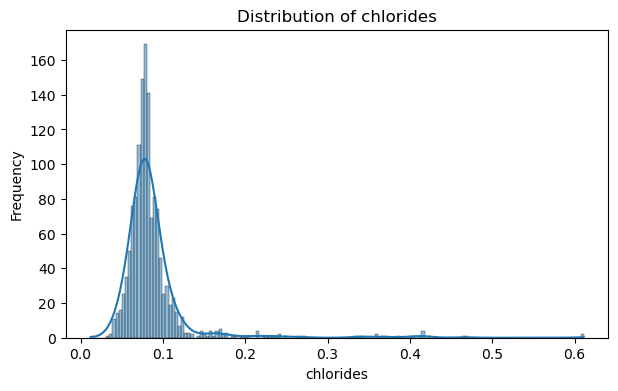

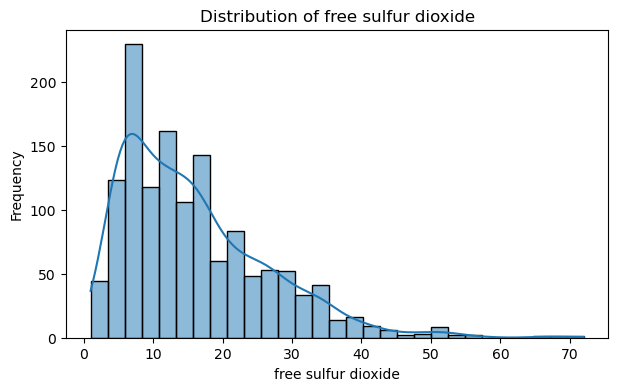

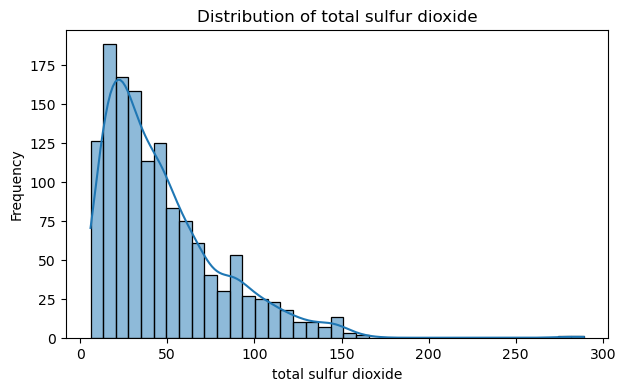

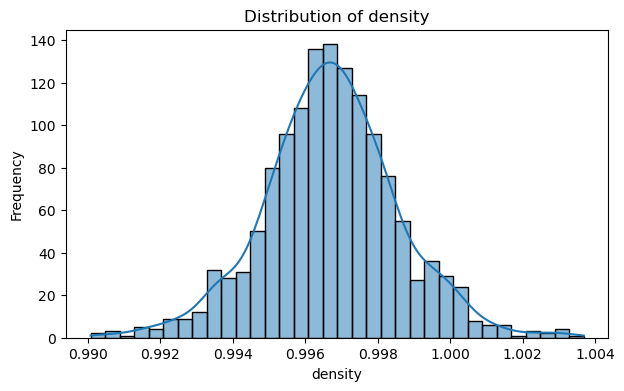

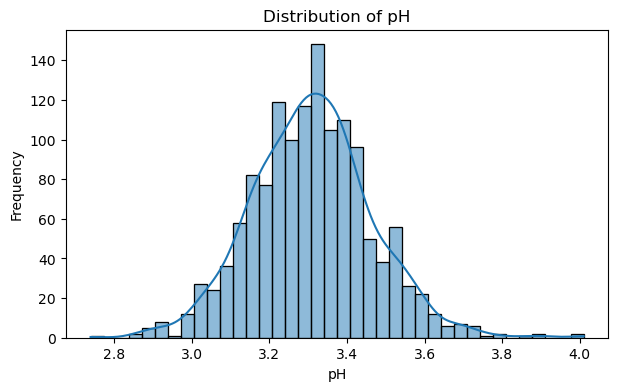

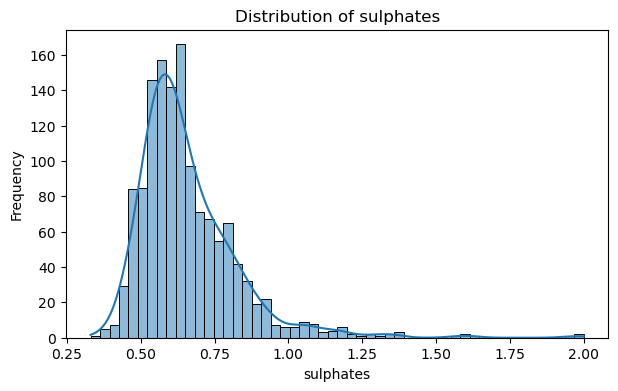

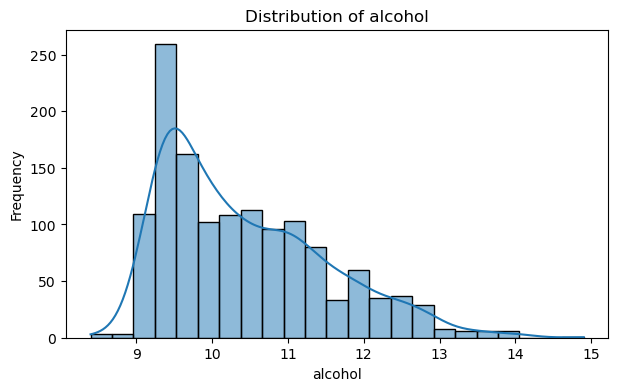

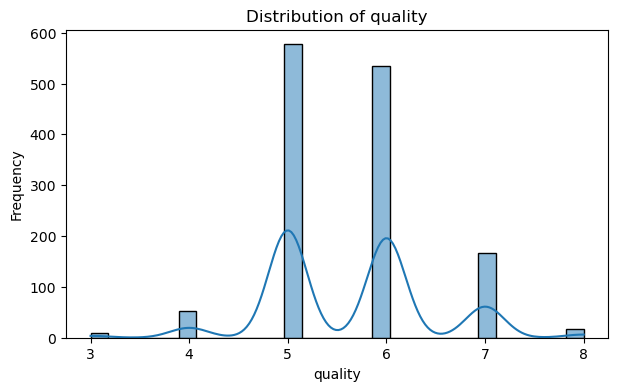

In [9]:
# histogram + KDE

import matplotlib.pyplot as plt
import seaborn as sns

numerics_cols = df.columns

for col in numerics_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

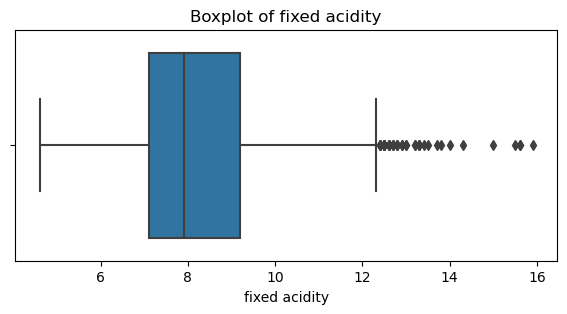

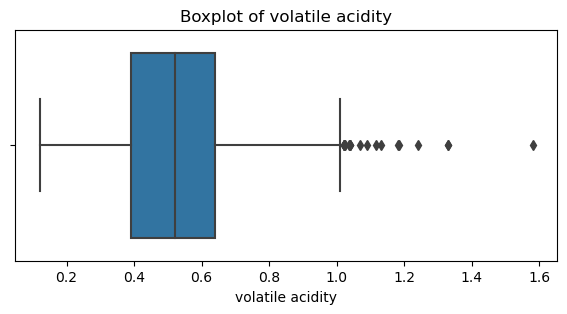

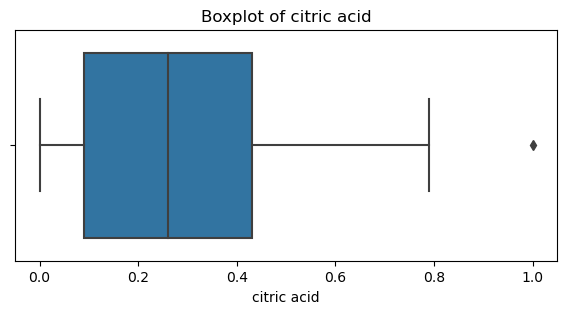

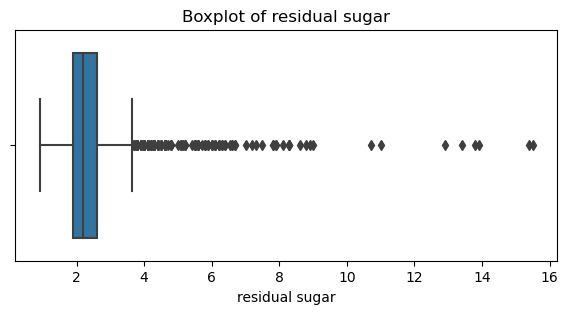

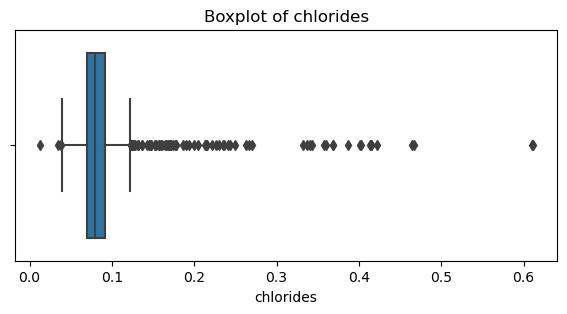

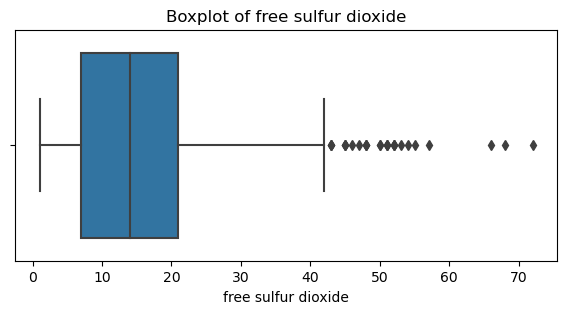

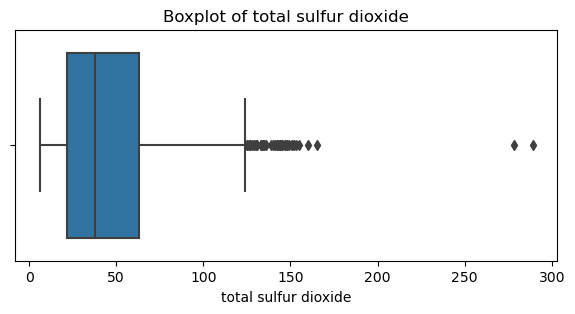

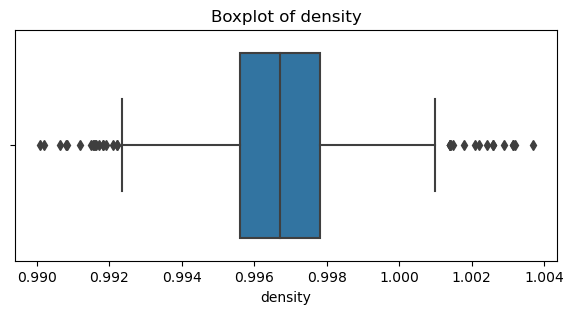

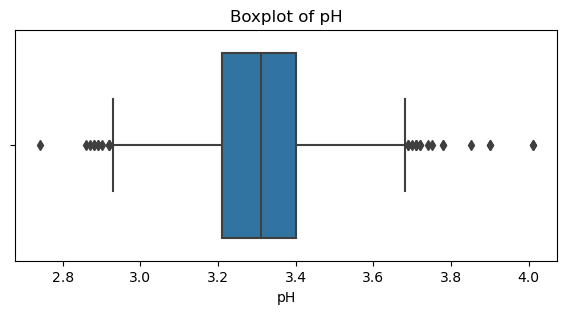

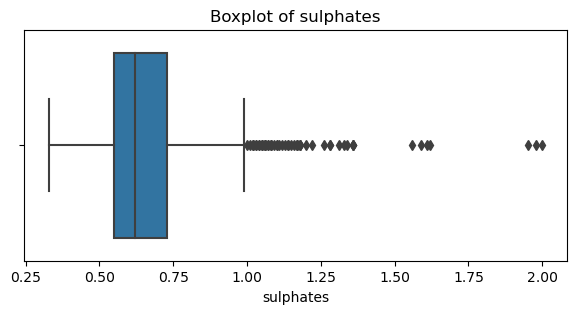

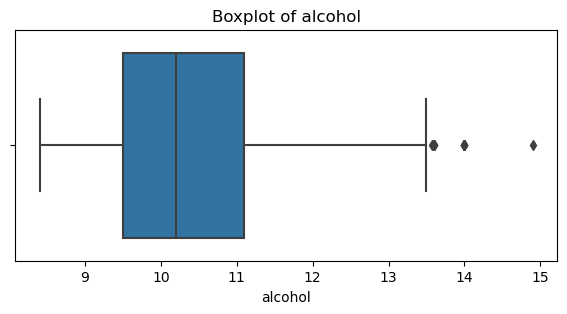

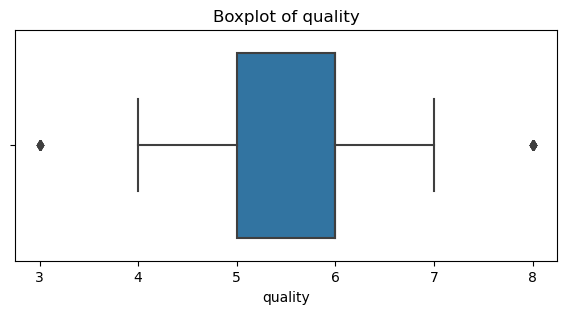

In [10]:
# Boxplot- Outlier Analysis
for col in numerics_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

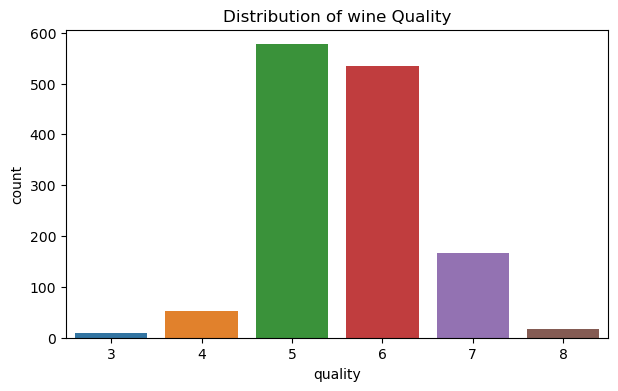

In [11]:
# Quality Distribution
plt.figure(figsize=(7,4))
sns.countplot(x='quality',data=df)
plt.title('Distribution of wine Quality')
plt.show()

In [12]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

## 2 Bivariate Analysis

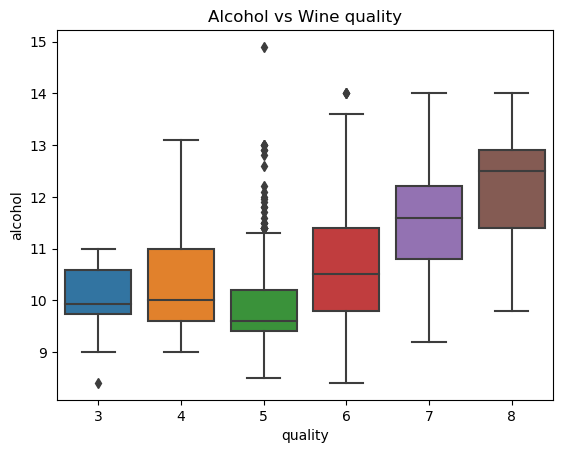

In [13]:
# Alcohol vs quality
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Wine quality')
plt.show()

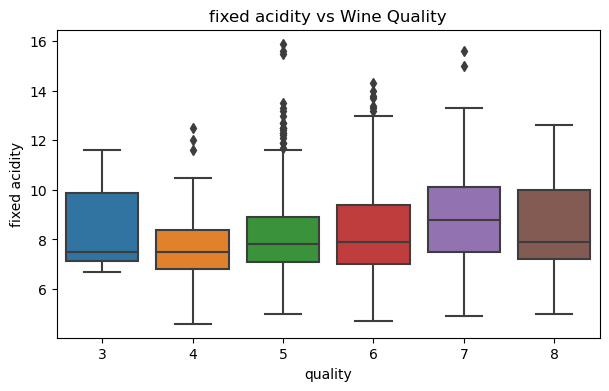

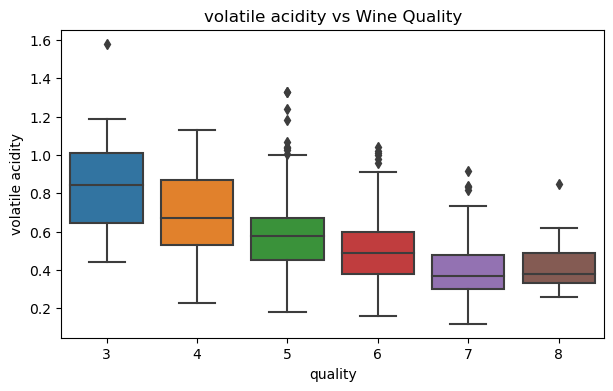

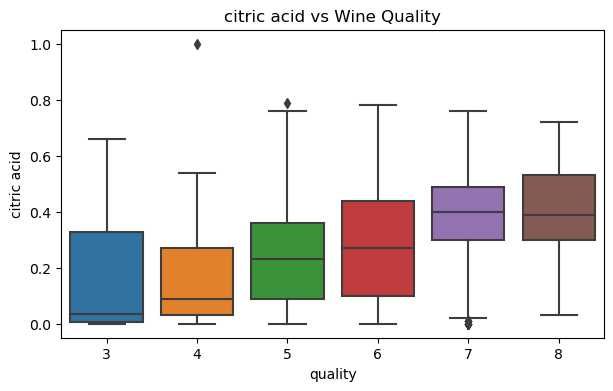

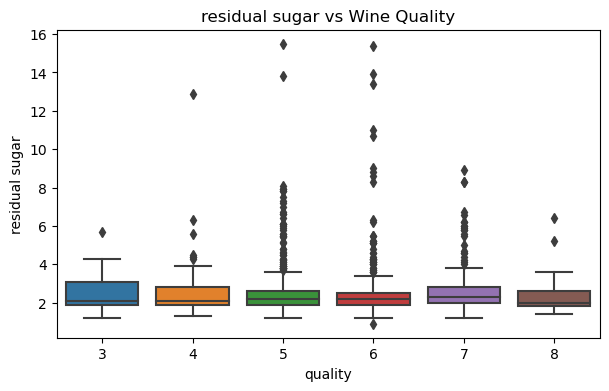

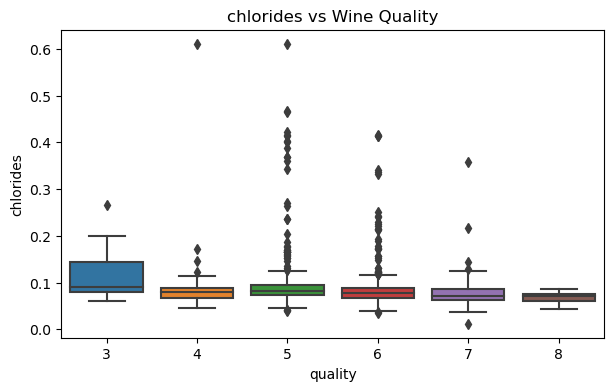

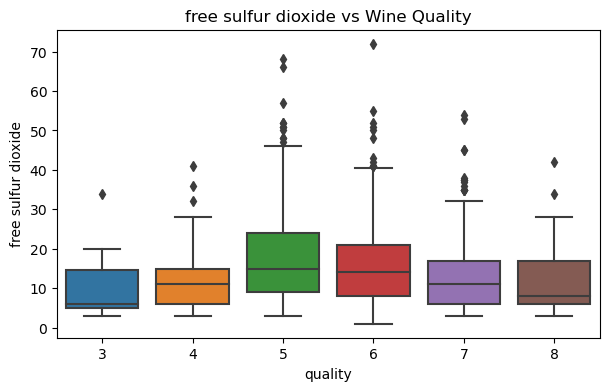

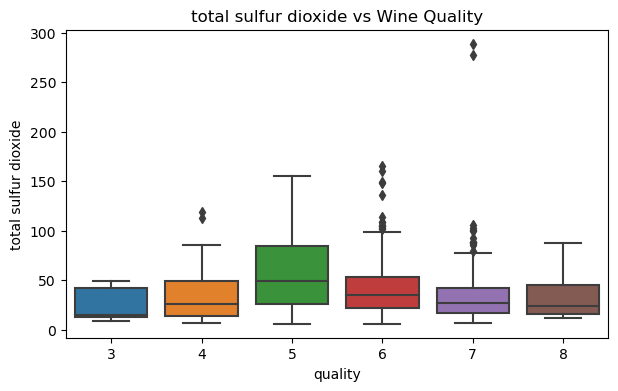

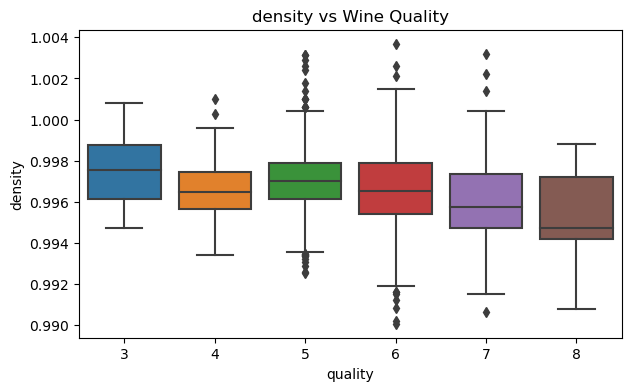

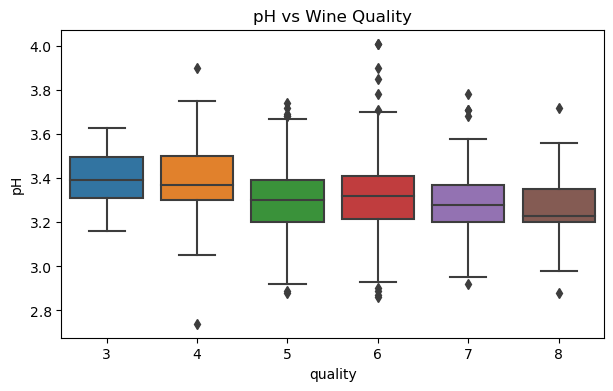

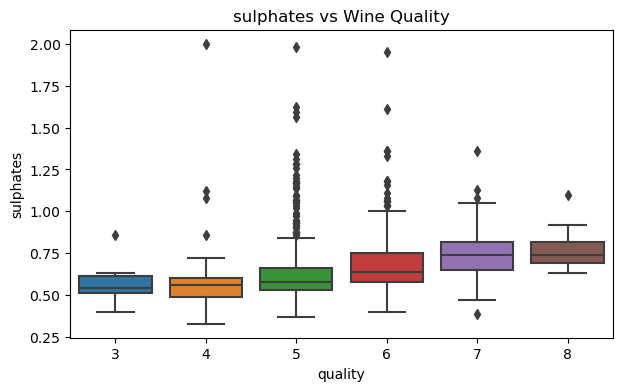

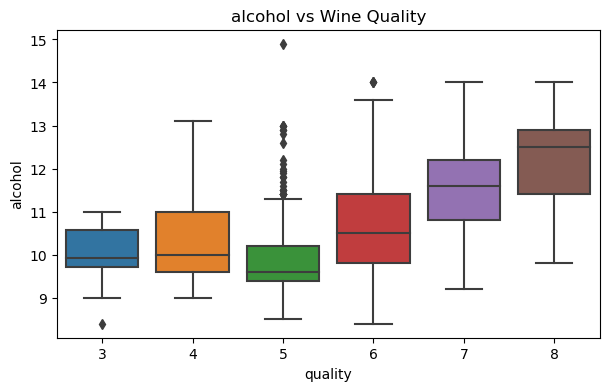

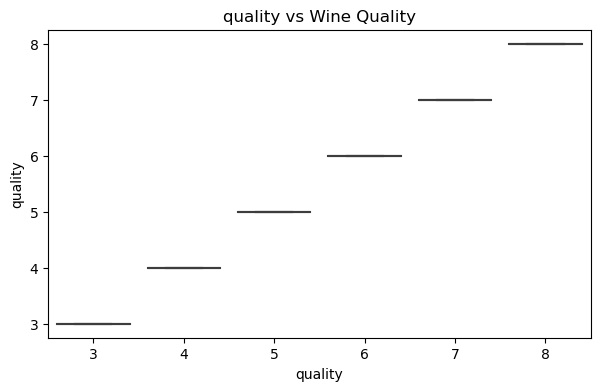

In [14]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']

for col in features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='quality', y=col, data=df)
    plt.title(f'{col} vs Wine Quality')
    plt.show()

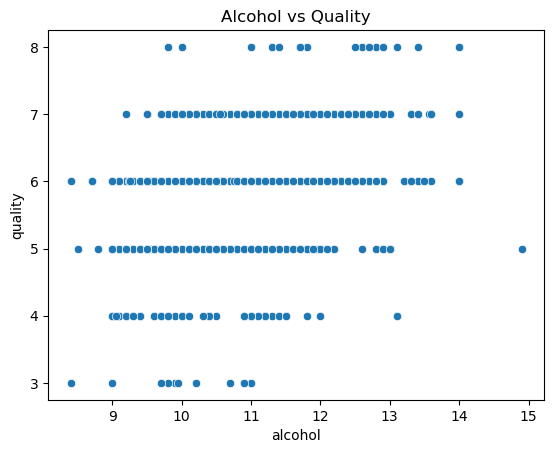

In [15]:
# Scatter Plot
sns.scatterplot(x='alcohol', y='quality', data=df)
plt.title('Alcohol vs Quality')
plt.show()

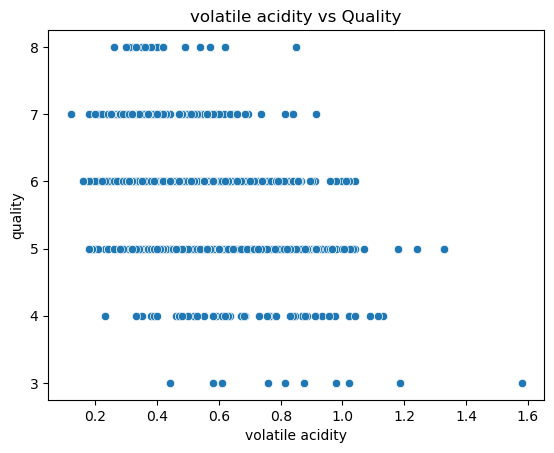

In [16]:
sns.scatterplot(x='volatile acidity', y='quality', data=df)
plt.title('volatile acidity vs Quality')
plt.show()

## 3 Multivariate Analysis

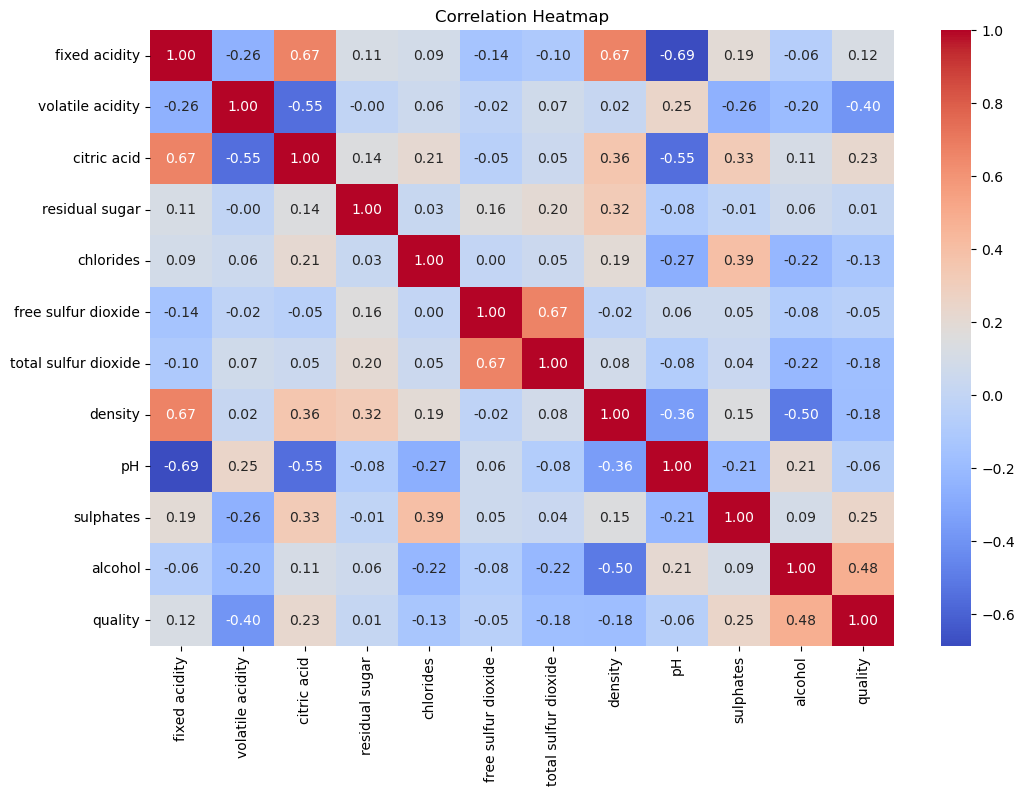

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, annot = True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

C:\Users\cse\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


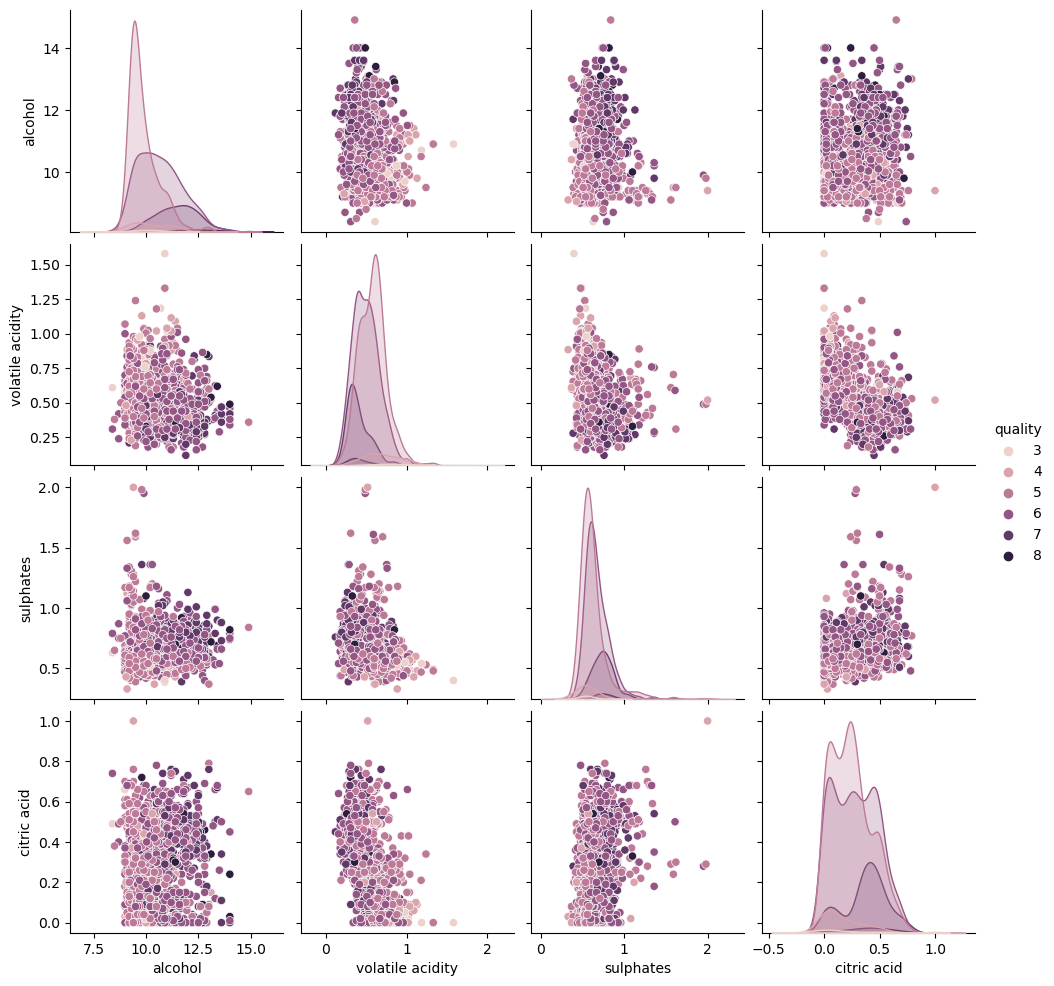

In [18]:
# pair Plot: Combination of histplot and scatterplot 
selected = ['alcohol', 'volatile acidity','sulphates', 'citric acid', 'quality']

sns.pairplot(df[selected],hue='quality')
plt.show()

In [19]:
# Multivariate Analysis Using Quality Groups
df['quality_group'] = pd.cut(
    df['quality'],
    bins=[0,5,6,10], # Used for Duration
    labels=['Low', 'Medium', 'High']
)

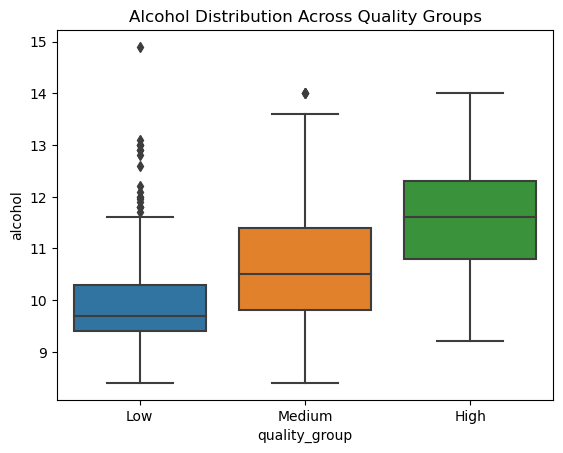

In [20]:
sns.boxplot(
    x='quality_group',
    y='alcohol',
    data=df
)

plt.title('Alcohol Distribution Across Quality Groups')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [22]:
x= df.drop('quality', axis=1)
y = df['quality']

In [23]:
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (1359, 12)
Y shape: (1359,)


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [25]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1087, 12)
X_test: (272, 12)
y_train: (1087,)
y_test: (272,)


In [26]:
criterion='entropy'

In [27]:
dt_model=DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [28]:
print(x.select_dtypes(exclude='number').columns)

Index(['quality_group'], dtype='object')


In [29]:
y=df['quality']

In [30]:
x=df.drop(columns=['quality', 'quality_group'], errors='ignore')

In [31]:
print(x.columns)
print(x.dtypes)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


In [32]:
df['quality_group'] = pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels=['Low','Medium','High'] )
print(x.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
y_train_pred = dt_model.predict(x_train)
y_test_pred = dt_model.predict(x_test)

In [37]:
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [38]:
test_accuracy=accuracy_score(y_test, y_test_pred)
print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.5147058823529411


In [39]:
print("precision:", 
       precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", 
      recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:",
      f1_score(y_test, y_test_pred, average='weighted'))

precision: 0.522762871909526
Recall: 0.5147058823529411
F1 Score: 0.5180964052287581


C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [40]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.09      0.08        11
           5       0.65      0.61      0.63       116
           6       0.50      0.50      0.50       107
           7       0.36      0.42      0.39        33
           8       0.00      0.00      0.00         3

    accuracy                           0.51       272
   macro avg       0.26      0.27      0.27       272
weighted avg       0.52      0.51      0.52       272



C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


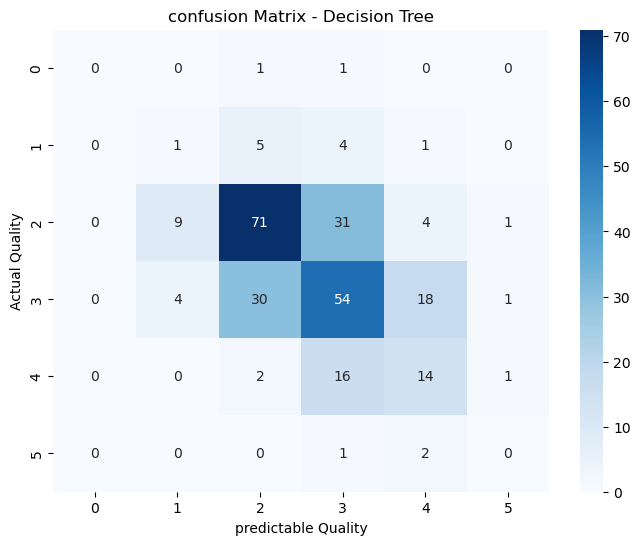

In [41]:
# confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d' , cmap='Blues')

plt.xlabel('predictable Quality')
plt.ylabel('Actual Quality')
plt.title('confusion Matrix - Decision Tree')
plt.show()

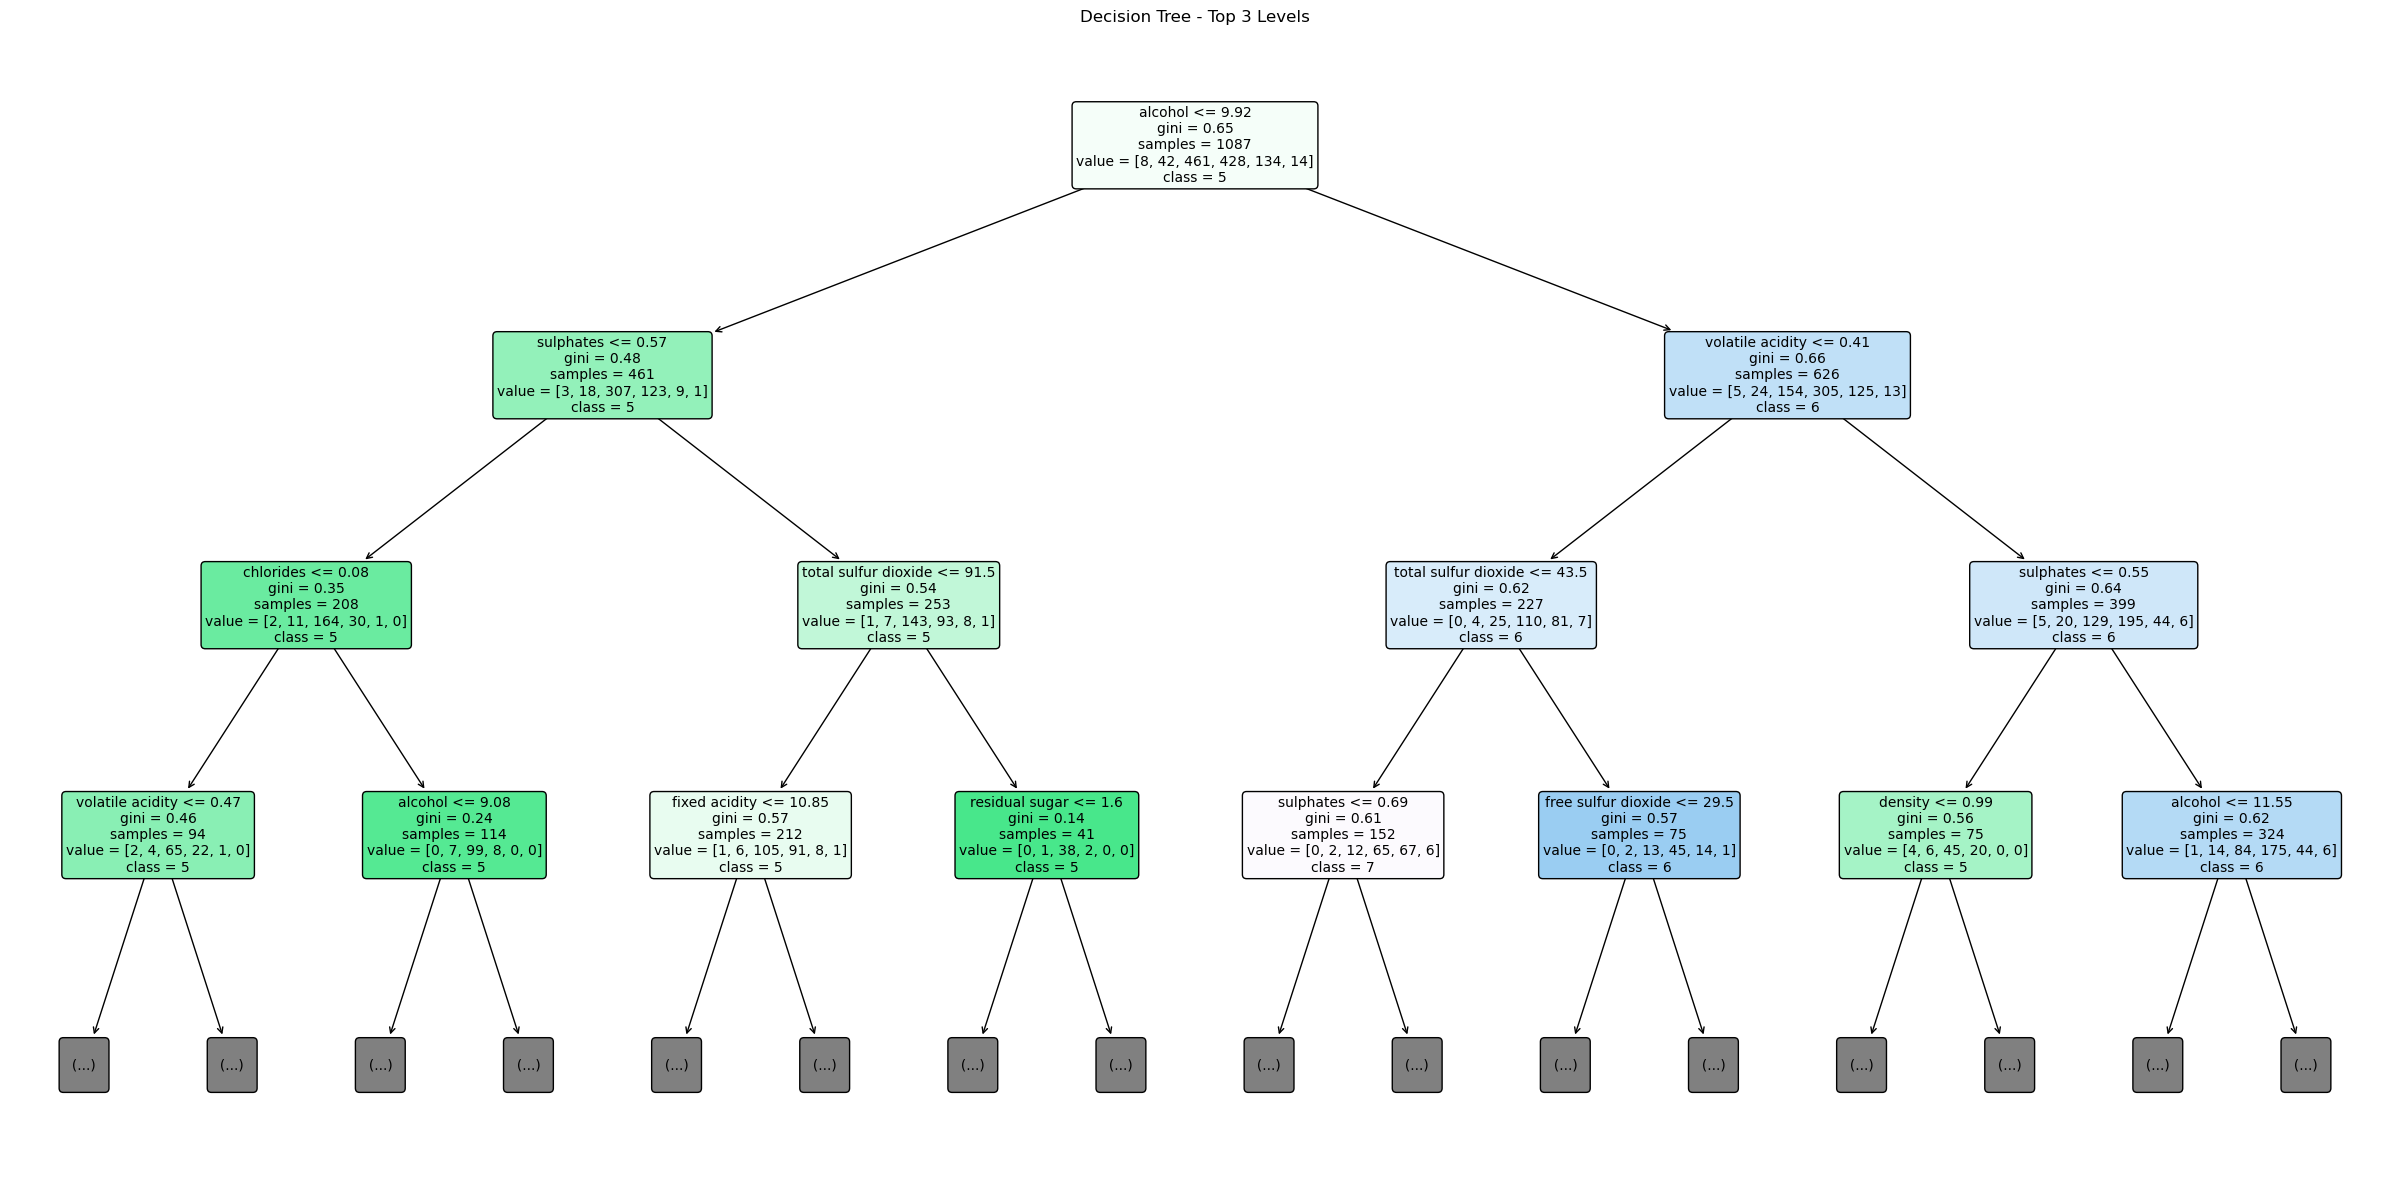

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=list(x.columns),
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2,
    fontsize=10,
    max_depth=3
)

plt.title("Decision Tree - Top 3 Levels", fontsize=12)
plt.tight_layout()
plt.show()


In [44]:
print("Tree Depth:",dt_model.get_depth())
print("Number of Leaves:",dt_model.get_n_leaves())

Tree Depth: 18
Number of Leaves: 307


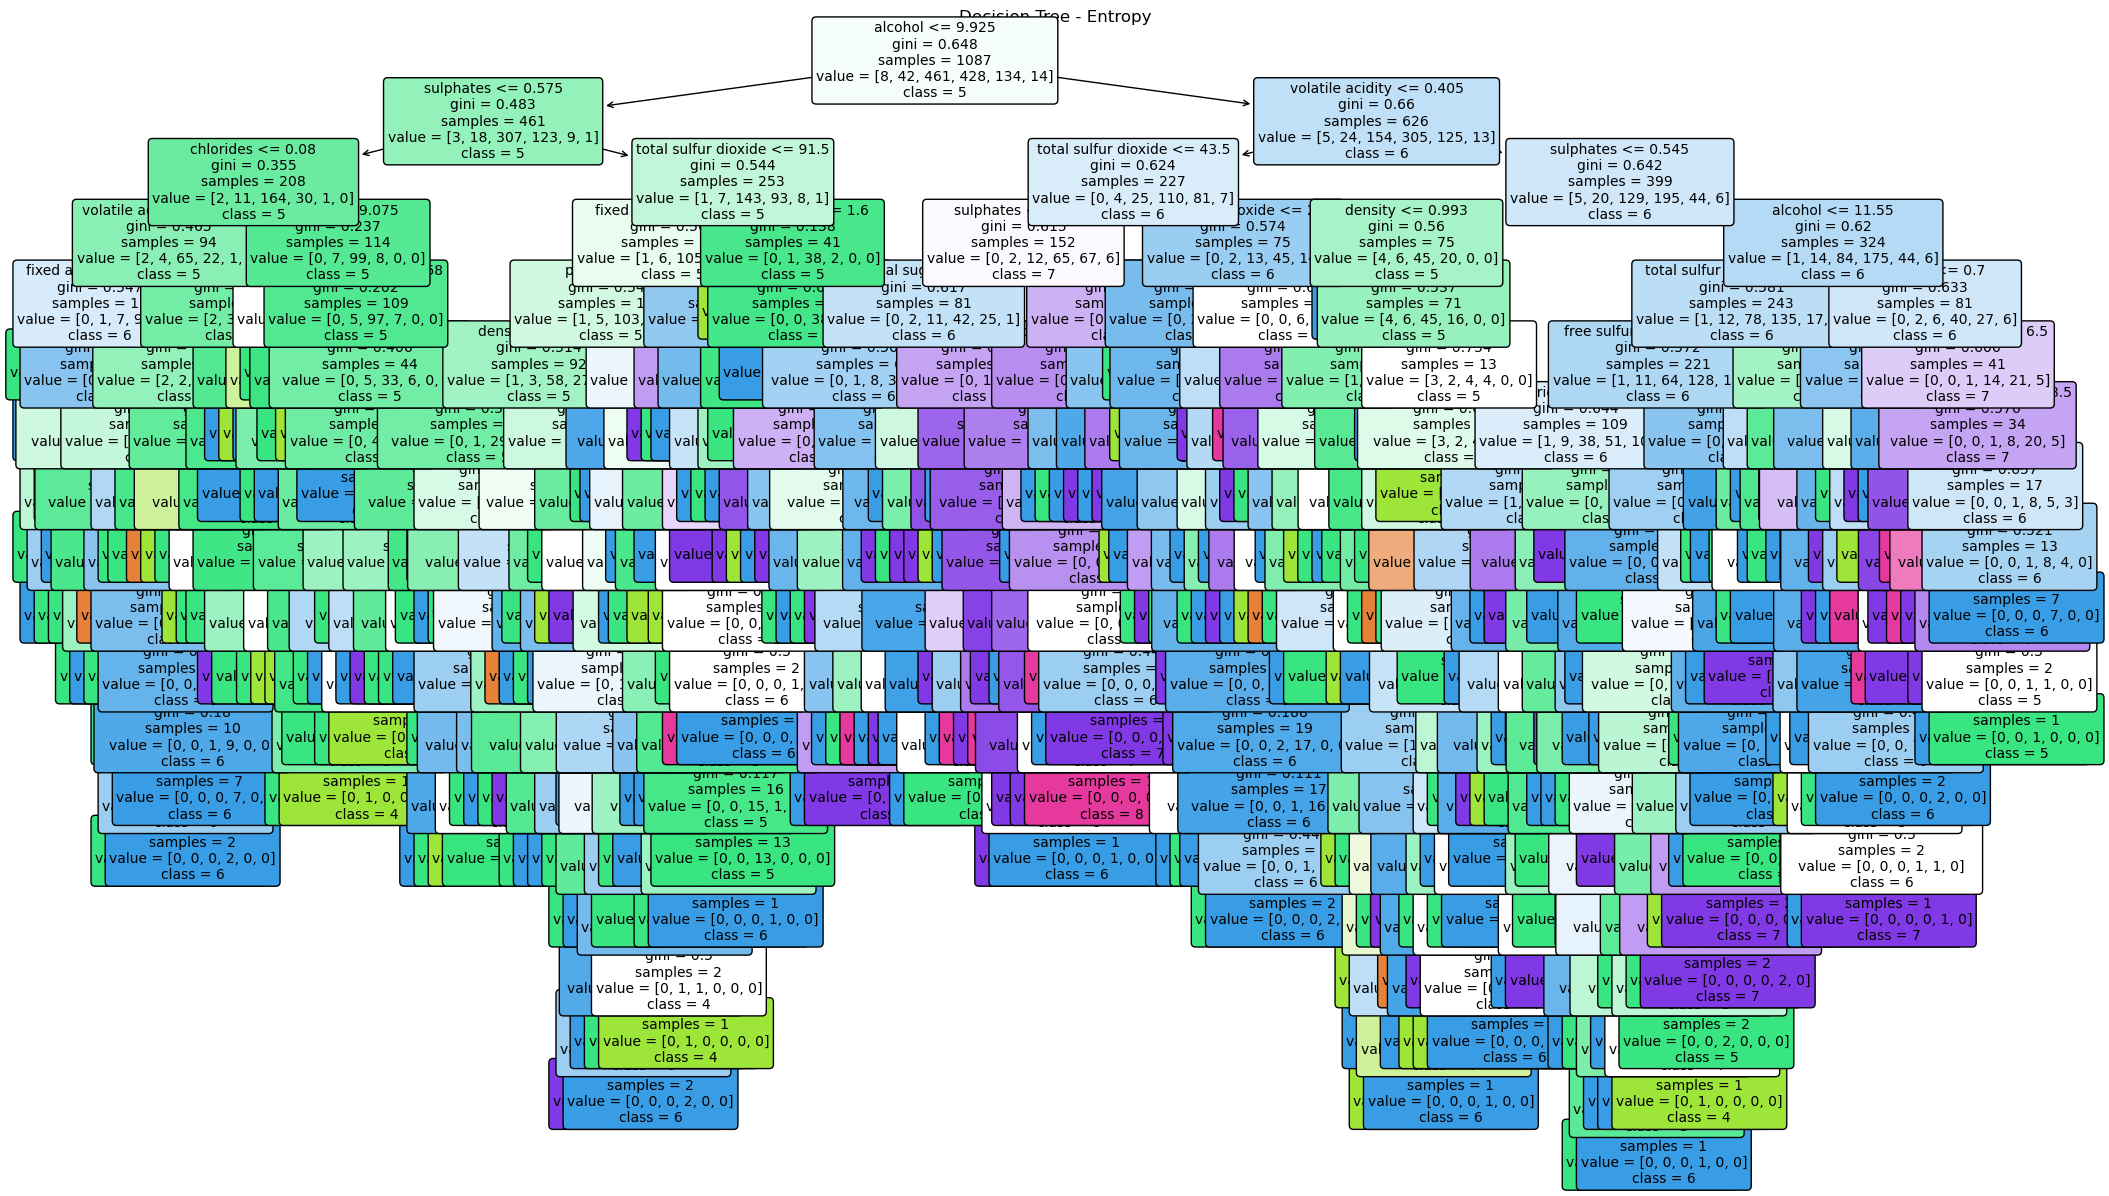

In [50]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))

plot_tree(
    dt_model,
    feature_names=list(x.columns),
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Entropy")
plt.show()

## ROC - AOC Curve

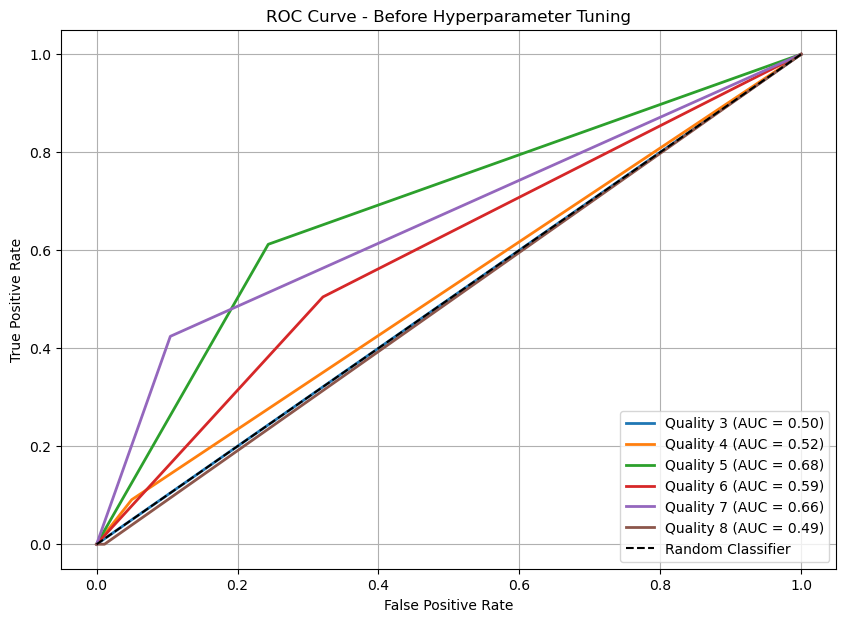

Overall ROC-AUC Before Tuning: 0.6348


In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get classes from the trained Decision Tree model
classes = dt_model.classes_

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_score = dt_model.predict_proba(x_test)

# Create ROC plot
plt.figure(figsize=(10, 7))

# Plot ROC curve for each class
for i, class_label in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'Quality {class_label} (AUC = {roc_auc:.2f})'
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black',
    label='Random Classifier'
)

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Before Hyperparameter Tuning')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calculate overall weighted ROC-AUC
overall_auc_before = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class='ovr',
    average='weighted'
)

print("Overall ROC-AUC Before Tuning:", round(overall_auc_before, 4))


## Hyperparametric Tuning 

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'criterion':['entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,8],
    'max_features':[None,'sqrt','log2'],
    'ccp_alpha':[0,0.001,0.005,0.01]     }
                    
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(x_train,y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best Cross validation accuracy")
print(grid.best_score_)

best_tree=grid.best_estimator_

Best Parameters
{'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best Cross validation accuracy
0.5814399864710607


In [60]:
y_pred= best_tree.predict(x_test)

print(classification_report(y_test, y_pred))
print("Accuracy=",accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.63      0.69      0.66       116
           6       0.53      0.54      0.54       107
           7       0.47      0.52      0.49        33
           8       0.00      0.00      0.00         3

    accuracy                           0.57       272
   macro avg       0.27      0.29      0.28       272
weighted avg       0.54      0.57      0.55       272

Accuracy= 0.5698529411764706


C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\cse\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Cross Validation

In [61]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(best_tree,x,y,cv=10,scoring='accuracy')

print(scores)

print("Average Accuracy=", scores.mean())

print("Std =", scores.std())

[0.46323529 0.60294118 0.61029412 0.5        0.58088235 0.59558824
 0.60294118 0.55147059 0.60294118 0.54814815]
Average Accuracy= 0.5658442265795207
Std = 0.047538408739019426


## Learning Curve

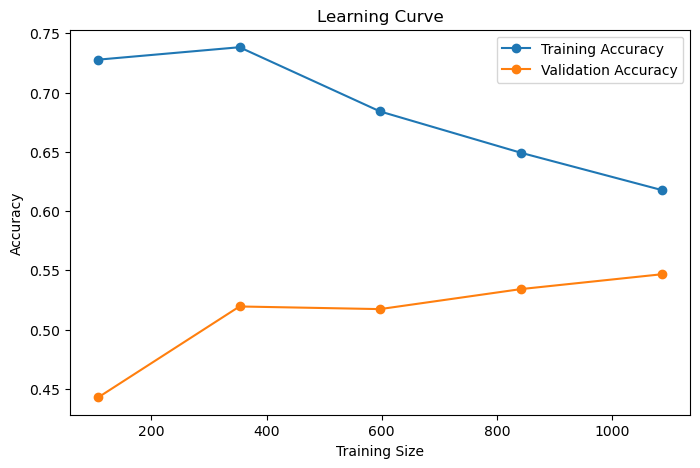

In [64]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    best_tree,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')

plt.legend()
plt.show()

In [69]:
from sklearn.model_selection import validation_curve

param_range=[2,3,4,5,6,7,8,9,10]

train_scores, test_score= validation_curve
(plot_tree(criterion='entropy', random_state=42), x, y, param_name="max_depth", param_range=param_range, cv=5)

plt_plot(param_range, train_score.mean(axis=1),label='Training')

plt_plot(param_range, test_score.mean(axis=1),label='Validation')

plt.legend()

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')

plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1956299011.py, line 6)

In [68]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

param_range = [2, 3, 4, 5, 6, 7, 8, 9, 10]

train_scores, test_scores = validation_curve(
    pl(criterion='entropy', random_state=42),
    x,
    y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='accuracy'
)

plt.plot(
    param_range,
    train_scores.mean(axis=1),
    label='Training'
)

plt.plot(
    param_range,
    test_scores.mean(axis=1),
    label='Validation'
)

plt.legend()

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')

plt.show()

NameError: name 'pl' is not defined